# ***Supervised Models***

In [57]:
# Library
import os
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Preprocessing**

In [58]:
# Download the Adult_Income dataset from Kaggle
dataset_path = kagglehub.dataset_download('serpilturanyksel/adult-income')

# construct the full path to the adult11.csv file.
file_path = os.path.join(dataset_path, 'adult11.csv')

# Load the dataset using pandas
adult = pd.read_csv(file_path)
adult.head()

Using Colab cache for faster access to the 'adult-income' dataset.


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [59]:
# Find Missing Values
adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [60]:
# label encoding for (income); convert  <=50K to 1 & >50K to 0
adult['salary'] = adult['salary'].map({'<=50K': 0, '>50K': 1})
adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [61]:
# Encode the categorical columns (using label encode)
categorical_col = ['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country'] # All categorical columns

# Apply Label encoding
for col in categorical_col:
    adult[col] = pd.Categorical(adult[col]).codes
display(adult.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,4,226802,1,7,4,7,3,2,1,0,0,40,39,0
1,38,4,89814,11,9,2,5,0,4,1,0,0,50,39,0
2,28,2,336951,7,12,2,11,0,4,1,0,0,40,39,1
3,44,4,160323,15,10,2,7,0,2,1,7688,0,40,39,1
4,18,0,103497,15,10,4,0,3,4,0,0,0,30,39,0


In [62]:
# Separate features (X) and target (y)
X_adult = adult.drop('salary', axis=1)
y_adult = adult['salary']

In [63]:
# (( Split the data into training and testing sets "70% train, 30% test" ))
X_adult_test, X_adult_train, y_adult_test, y_adult_train = train_test_split(X_adult, y_adult, test_size=0.3, random_state=42)

In [64]:
# Standardiztion
scaler = StandardScaler()
# just select numerical column
num_of_col = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
X_adult_train_scaled = scaler.fit_transform(X_adult_train[num_of_col])
X_adult_test_scaled = scaler.transform(X_adult_test[num_of_col])

# **Model Building & Evaluation then Visualization**

> ***Logistic Regression model***

In [65]:
# Logistic Regression model
LR_model = LogisticRegression(max_iter=2500)

# Train the model
LR_model.fit(X_adult_train_scaled, y_adult_train)

LogisticRegression(max_iter=2500)

In [66]:
# Making predictions on the test set
y_adult_pred_LR = LR_model.predict(X_adult_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_adult_pred_LR)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [67]:
# Compute metrics Logistic Regression
LR_accuracy_adult = accuracy_score(y_adult_test, y_adult_pred_LR) # accuracy

LR_precision_adult = precision_score(y_adult_test, y_adult_pred_LR) # precision

LR_recall_adult = recall_score(y_adult_test, y_adult_pred_LR) # recall

LR_f1_adult = f1_score(y_adult_test, y_adult_pred_LR) # f1

LR_roc_auc_adult = roc_auc_score(y_adult_test, LR_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("Logistic Regression Evaluation:")
print(f"Accuracy: {LR_accuracy_adult:.4f}")
print(f"Precision: {LR_precision_adult:.4f}")
print(f"Recall: {LR_recall_adult:.4f}")
print(f"F1-Score: {LR_f1_adult:.4f}")
print(f"ROC-AUC Score: {LR_roc_auc_adult:.4f}")

Logistic Regression Evaluation:
Accuracy: 0.8128
Precision: 0.7117
Recall: 0.3795
F1-Score: 0.4950
ROC-AUC Score: 0.8291


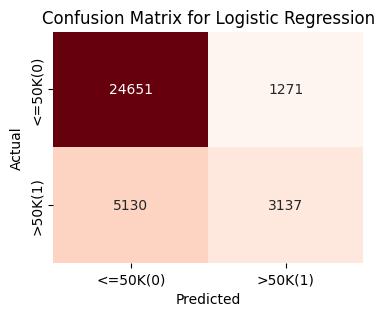

In [68]:
# confusion matrices for LR
LR_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_LR)
plt.figure(figsize=(4, 3))
sns.heatmap(LR_cm_adult, annot=True, fmt='d', cmap='Reds', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()



---



> ***Naive Bayes model***

In [69]:
# Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_adult_train_scaled, y_adult_train)

GaussianNB()

In [70]:
# Making predictions on the test set
y_adult_pred_nb = nb_model.predict(X_adult_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_adult_pred_nb)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [71]:
# Compute metrics
nb_accuracy = accuracy_score(y_adult_test, y_adult_pred_nb) # accuracy

nb_precision = precision_score(y_adult_test, y_adult_pred_nb) # precision

nb_recall = recall_score(y_adult_test, y_adult_pred_nb) # recall

nb_f1 = f1_score(y_adult_test, y_adult_pred_nb) # f1

nb_roc_auc = roc_auc_score(y_adult_test, nb_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("\nNaive Bayes Evaluation:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print(f"ROC-AUC Score: {nb_roc_auc:.4f}")


Naive Bayes Evaluation:
Accuracy: 0.7947
Precision: 0.6663
Recall: 0.3022
F1-Score: 0.4158
ROC-AUC Score: 0.8288


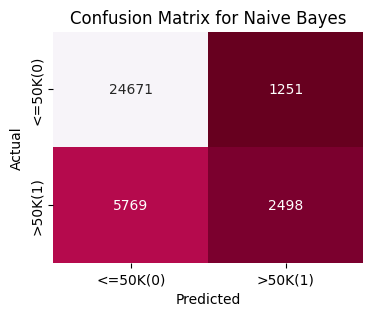

In [72]:
# confusion matrices for Naive Bayes
nb_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_nb)
plt
plt.figure(figsize=(4, 3))
sns.heatmap(nb_cm_adult, annot=True, fmt='d', cmap='PuRd_r', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()



---



> ***BernoulliNB***

In [73]:
# BernoulliNB
b_model = BernoulliNB()

# Train the model
b_model.fit(X_adult_train_scaled, y_adult_train)

BernoulliNB()

In [74]:
# # Making predictions on the test set
y_adult_pred_b = b_model.predict(X_adult_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_adult_pred_b)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [75]:
# Compute metrics
b_accuracy = accuracy_score(y_adult_test, y_adult_pred_b) # accuracy

b_precision = precision_score(y_adult_test, y_adult_pred_b) # precision

b_recall = recall_score(y_adult_test, y_adult_pred_b) # recall

b_f1 = f1_score(y_adult_test, y_adult_pred_b) # f1

b_roc_auc = roc_auc_score(y_adult_test, b_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("\nBernoulli Naive Bayes Evaluation:")
print(f"Accuracy: {b_accuracy:.4f}")
print(f"Precision: {b_precision:.4f}")
print(f"Recall: {b_recall:.4f}")
print(f"F1-Score: {b_f1:.4f}")
print(f"ROC-AUC Score: {b_roc_auc:.4f}")


Bernoulli Naive Bayes Evaluation:
Accuracy: 0.8008
Precision: 0.6572
Recall: 0.3678
F1-Score: 0.4717
ROC-AUC Score: 0.7931


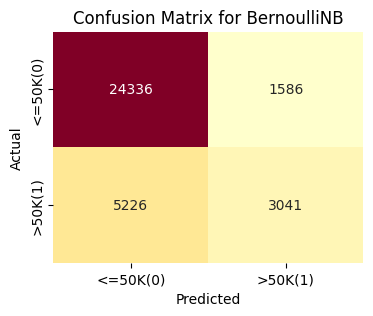

In [76]:
# confusion matrices for BernoulliNB
b_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_b)
plt.figure(figsize=(4, 3))
sns.heatmap(b_cm_adult, annot=True, fmt='d', cmap='YlOrRd', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for BernoulliNB')
plt.show()



---



> ***Support Vector Machine model***

In [77]:
# SVM
svm_model = SVC(probability=True)

# Train the model
svm_model.fit(X_adult_train_scaled, y_adult_train)

SVC(probability=True)

In [78]:
# # Making predictions on the test set
y_adult_pred_svm = svm_model.predict(X_adult_test_scaled)

# (predictions) vs (actual values)
print("Predicted values:", y_adult_pred_svm)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [79]:
# Compute metrics
svm_accuracy = accuracy_score(y_adult_test, y_adult_pred_svm) # accuracy

svm_precision = precision_score(y_adult_test, y_adult_pred_svm) # precision

svm_recall = recall_score(y_adult_test, y_adult_pred_svm) # recall

svm_f1 = f1_score(y_adult_test, y_adult_pred_svm) # f1

svm_roc_auc = roc_auc_score(y_adult_test, svm_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("\nSupport Vector Machine Evaluation:")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}")
print(f"ROC-AUC Score: {svm_roc_auc:.4f}")


Support Vector Machine Evaluation:
Accuracy: 0.8207
Precision: 0.7980
Recall: 0.3461
F1-Score: 0.4828
ROC-AUC Score: 0.8082


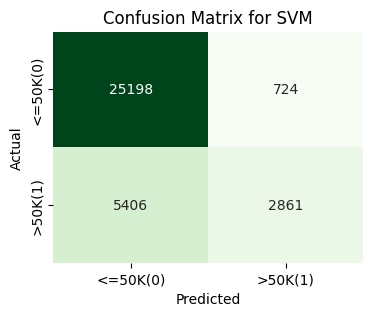

In [80]:
# confusion matrices for SVM
svm_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_svm)
plt.figure(figsize=(4, 3))
sns.heatmap(svm_cm_adult, annot=True, fmt='d', cmap='Greens', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM')
plt.show()



---



# **Model Performance Comparison**

In [81]:
# Get the predicted probabilities for the positive class for each model
y_prob_LR = LR_model.predict_proba(X_adult_test_scaled)[:, 1]
y_prob_nb = nb_model.predict_proba(X_adult_test_scaled)[:, 1]
y_prob_bir = b_model.predict_proba(X_adult_test_scaled)[:, 1]
y_prob_svm = svm_model.predict_proba(X_adult_test_scaled)[:, 1]

# Calculate the False Positive Rate, True Positive Rate, and thresholds
fpr_log, tpr_log, _ = roc_curve(y_adult_test, y_prob_LR)
fpr_gnb, tpr_gnb, _ = roc_curve(y_adult_test, y_prob_nb)
fpr_bnb, tpr_bnb, _ = roc_curve(y_adult_test, y_prob_bir)
fpr_svm, tpr_svm, _ = roc_curve(y_adult_test, y_prob_svm)

# Calculate the Area Under the ROC Curve
auc_log = roc_auc_score(y_adult_test, y_prob_LR)
auc_gnb = roc_auc_score(y_adult_test, y_prob_nb)
auc_bnb = roc_auc_score(y_adult_test, y_prob_bir)
auc_svm = roc_auc_score(y_adult_test, y_prob_svm)

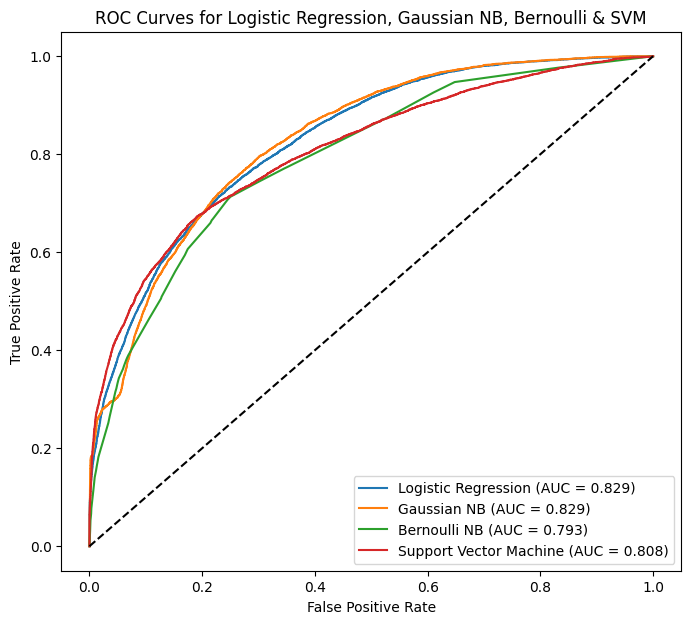

In [82]:
# plot the carve
plt.figure(figsize=(8, 7))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_gnb, tpr_gnb, label=f"Gaussian NB (AUC = {auc_gnb:.3f})")
plt.plot(fpr_bnb, tpr_bnb, label=f"Bernoulli NB (AUC = {auc_bnb:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"Support Vector Machine (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression, Gaussian NB, Bernoulli & SVM")
plt.legend(loc="lower right")
plt.show()

In [83]:
test_accuracies = (
    accuracy_score(y_adult_test, y_adult_pred_LR),
    accuracy_score(y_adult_test, y_adult_pred_nb),
    accuracy_score(y_adult_test, y_adult_pred_b),
    accuracy_score(y_adult_test, y_adult_pred_svm)
)

test_precisions = (
    precision_score(y_adult_test, y_adult_pred_LR),
    precision_score(y_adult_test, y_adult_pred_nb),
    precision_score(y_adult_test, y_adult_pred_b),
    precision_score(y_adult_test, y_adult_pred_svm)
)

test_recalls = (
    recall_score(y_adult_test, y_adult_pred_LR),
    recall_score(y_adult_test, y_adult_pred_nb),
    recall_score(y_adult_test, y_adult_pred_b),
    recall_score(y_adult_test, y_adult_pred_svm)
)

test_f1_scores = (
    f1_score(y_adult_test, y_adult_pred_LR),
    f1_score(y_adult_test, y_adult_pred_nb),
    f1_score(y_adult_test, y_adult_pred_b),
    f1_score(y_adult_test, y_adult_pred_svm)
)

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [test_accuracies[0], test_precisions[0], test_recalls[0], test_f1_scores[0]],
    'Gaussian Naive Bayes': [test_accuracies[1], test_precisions[1], test_recalls[1], test_f1_scores[1]],
    'Birnoulli': [test_accuracies[2], test_precisions[2], test_recalls[2], test_f1_scores[2]],
    'Support Vector Machine': [test_accuracies[3], test_precisions[3], test_recalls[3], test_f1_scores[3]]
}

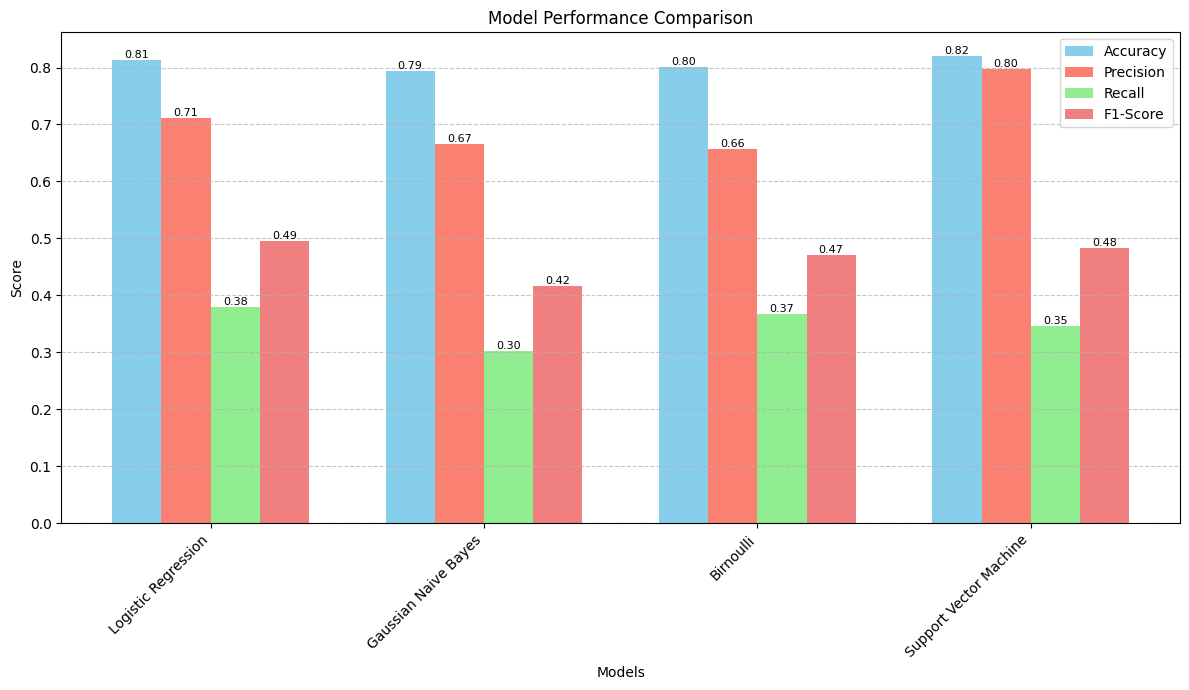

In [84]:
fig, ax = plt.subplots(figsize=(12, 7))

model_names = ['Logistic Regression', 'Gaussian Naive Bayes', 'Birnoulli', 'Support Vector Machine']
metrics_to_plot_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Data extraction for each metric across all models
accuracies = [comparison_data[model_name][0] for model_name in model_names]
precisions = [comparison_data[model_name][1] for model_name in model_names]
recalls = [comparison_data[model_name][2] for model_name in model_names]
f1_scores = [comparison_data[model_name][3] for model_name in model_names]

num_models = len(model_names)

# X-axis positions for each group of bars (each model)
x = np.arange(num_models)

# Width of each individual bar
width = 0.18

# Plotting bars for each metric
bars1 = ax.bar(x - 1.5*width, accuracies, width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x - 0.5*width, precisions, width, label='Precision', color='salmon')
bars3 = ax.bar(x + 0.5*width, recalls, width, label='Recall', color='lightgreen')
bars4 = ax.bar(x + 1.5*width, f1_scores, width, label='F1-Score', color='lightcoral')

# Add text labels on top of each bar
for container in [bars1, bars2, bars3, bars4]:
    for bar_patch in container:
        height = bar_patch.get_height()
        ax.text(bar_patch.get_x() + bar_patch.get_width() / 2, height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()